In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data import *
from data_utils import len_active_terms, f_active_terms, f_ground_truth
from information_content import deprecated, compute_information_content, get_ancestors0

# Statistiques descriptives sur l'arbre HPO

<Axes: >

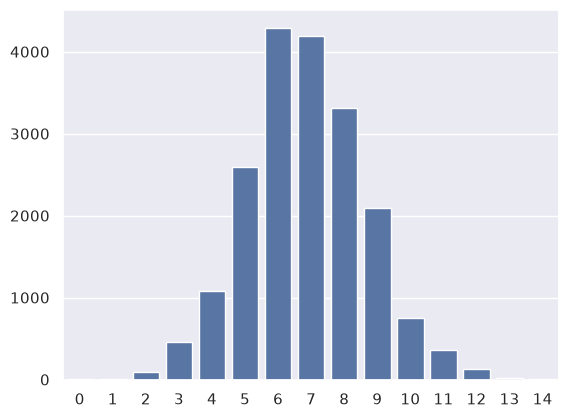

In [2]:
n_nodes = G_hpo_work.number_of_nodes()
n_edges = G_hpo_work.number_of_edges()

prof = [v for v in depths.values()]
x,y = np.unique(prof, return_counts=True)
sns.set_theme()
sns.barplot(x=x,y=y)

In [3]:
import pandas as pd
out_deg = [v for v in dict(G_hpo_work.in_degree()).values()]
print(np.mean(out_deg), np.max(out_deg), np.min(out_deg), np.std(out_deg))
df = pd.read_csv("../data/HPOs.csv", sep=";")

1.2210819452323243 193 0 3.375027598225367


In [8]:
# Les 7 sous ontologies
inheritance = nx.ancestors(G_hpo_work, 'HP:0000005')
print(len(list(inheritance)))
onset = nx.ancestors(G_hpo_work, 'HP:0012823')
print(len(list(onset)))
abnormality = nx.ancestors(G_hpo_work, 'HP:0000118')
print(len(list(abnormality)))
history = nx.ancestors(G_hpo_work, 'HP:0032443')
print(len(list(history)))
biospecimen = nx.ancestors(G_hpo_work, 'HP:0020228')
print(len(list(biospecimen)))
blood = nx.ancestors(G_hpo_work, 'HP:0032223')
print(len(list(blood)))
frequency = nx.ancestors(G_hpo_work, 'HP:0040279')
print(len(list(frequency)))
print(len(G_hpo_work.nodes))
categories = {
    'inheritance': list(inheritance), 
    'onset' : list(onset), 
    'abnormality' : list(abnormality), 
    'history' : list(history), 
    'biospecimen' : list(biospecimen),
    'blood' : list(blood), 
    'frequency' : list(frequency)}

40
357
18690
198
85
8
6
19391


# Statistiques descriptives sur les maladies hpoa

In [21]:
# Nombre moyen de termes hpo par maladie
work_omim = work_omim.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha = work_orpha.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha2 = work_orpha2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols = [c for c in work_omim.columns if c.startswith("HP:")]

gt_set, valid_omim, valid_orpha = f_ground_truth(work_omim, work_orpha, df_orpha_omim_exact)
#hpo_cols2 = [c for c in work_oprha2.columns if c.startswith('HP')]

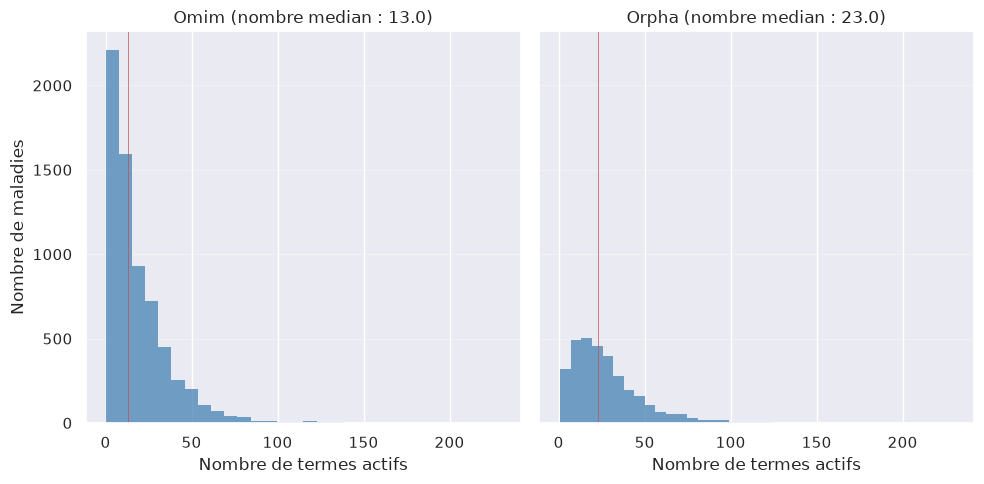

In [15]:
X_omim = work_omim[hpo_cols].astype(int).values    # shape (n_omim, n_hpo)
X_orpha = work_orpha[hpo_cols].astype(int).values  # shape (n_orpha, n_hpo)

n_omim = X_omim.sum(axis=1)    
m_orpha = X_orpha.sum(axis=1) 

sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(n_omim, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.axvline(np.median(n_omim), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title(f"Omim (nombre median : {np.median(n_omim).round(0)})")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(m_orpha, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.axvline(np.median(m_orpha), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title(f"Orpha (nombre median : {np.median(m_orpha).round(0)})")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
common_matrix = X_omim @ X_orpha.T

gt_df = pd.DataFrame(list(gt_set), columns=['omim_pos', 'orpha_pos'])

omim_pos = gt_df['omim_pos'].values
orpha_pos = gt_df['orpha_pos'].values

gt_df['termes_communs'] = common_matrix[omim_pos, orpha_pos]
gt_df['n_omim'] = n_omim[omim_pos]
gt_df['m_orpha'] = m_orpha[orpha_pos]

denom = gt_df['n_omim'] + gt_df['m_orpha']
gt_df['score'] = np.where(denom > 0, 2 * gt_df['termes_communs'] / denom, np.nan)

# Récupérer les vrais identifiants pour lecture/export
gt_df['omim_id'] = work_omim['database_id'].values[omim_pos]
gt_df['orpha_id'] = work_orpha['database_id'].values[orpha_pos]

df_scores = gt_df[['omim_id', 'orpha_id', 'n_omim', 'm_orpha', 'termes_communs', 'score']]
print(df_scores.describe())
df_scores.head()

            n_omim      m_orpha  termes_communs        score
count  2217.000000  2217.000000     2217.000000  2217.000000
mean     22.799278    27.464592        8.774470     0.328206
std      20.957944    20.191161        8.308504     0.169264
min       0.000000     2.000000        0.000000     0.000000
25%       8.000000    13.000000        3.000000     0.214286
50%      17.000000    22.000000        6.000000     0.322581
75%      31.000000    36.000000       12.000000     0.434783
max     193.000000   185.000000       59.000000     1.000000


,omim_id,orpha_id,n_omim,m_orpha,termes_communs,score
0,OMIM:201180,ORPHA:1784,28,29,8,0.280702
1,OMIM:249600,ORPHA:2557,11,32,3,0.139535
2,OMIM:602484,ORPHA:2840,11,10,0,0.000000
3,OMIM:231680,ORPHA:26791,42,57,18,0.363636
4,OMIM:214800,ORPHA:138,89,94,37,0.404372


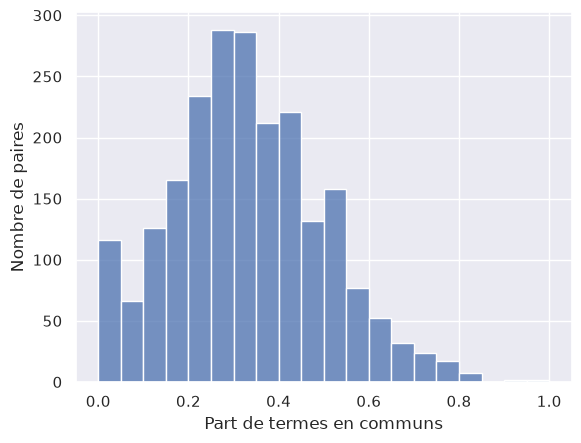

In [23]:
sns.set_theme()
sns.histplot(df_scores['score'], bins=20)

plt.xlabel("Part de termes en communs")
plt.ylabel("Nombre de paires")
plt.show()

In [27]:
import tsw
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols}
w_omim_P = tsw.propagate_terms(work_omim,  hpo_cols, ancestors, depths, k=3)
w_orpha_P = tsw.propagate_terms(work_orpha, hpo_cols, ancestors, depths, k=3)

#w_omim_P2 = tsw.propagate_terms(work_omim2,  hpo_cols2, ancestors, depths, k=3)
#w_orpha_P2 = tsw.propagate_terms(work_orpha2, hpo_cols2, ancestors, depths, k=3)

In [ ]:
X_omimP = w_omim_P[hpo_cols].astype(int).values    # shape (n_omim, n_hpo)
X_orphaP = w_orpha_P[hpo_cols].astype(int).values  # shape (n_orpha, n_hpo)

n_omimP = X_omimP.sum(axis=1)    
m_orphaP = X_orphaP.sum(axis=1) 
common_matrix = X_omimP @ X_orphaP.T

gt_df = pd.DataFrame(list(gt_set), columns=['omim_pos', 'orpha_pos'])

omim_pos = gt_df['omim_pos'].values
orpha_pos = gt_df['orpha_pos'].values

gt_df['termes_communs'] = common_matrix[omim_pos, orpha_pos]
gt_df['n_omim'] = n_omimP[omim_pos]
gt_df['m_orpha'] = m_orphaP[orpha_pos]

denom = gt_df['n_omim'] + gt_df['m_orpha']
gt_df['score'] = np.where(denom > 0, 2 * gt_df['termes_communs'] / denom, np.nan)

# Récupérer les vrais identifiants pour lecture/export
gt_df['omim_id'] = w_omim_P['database_id'].values[omim_pos]
gt_df['orpha_id'] = w_orpha_P['database_id'].values[orpha_pos]

df_scores = gt_df[['omim_id', 'orpha_id', 'n_omim', 'm_orpha', 'termes_communs', 'score']]
print(df_scores.describe())
df_scores.head()

In [ ]:
sns.set_theme()
sns.histplot(df_scores['score'], bins=20)

plt.xlabel("Part de termes en communs")
plt.ylabel("Nombre de paires")
plt.show()

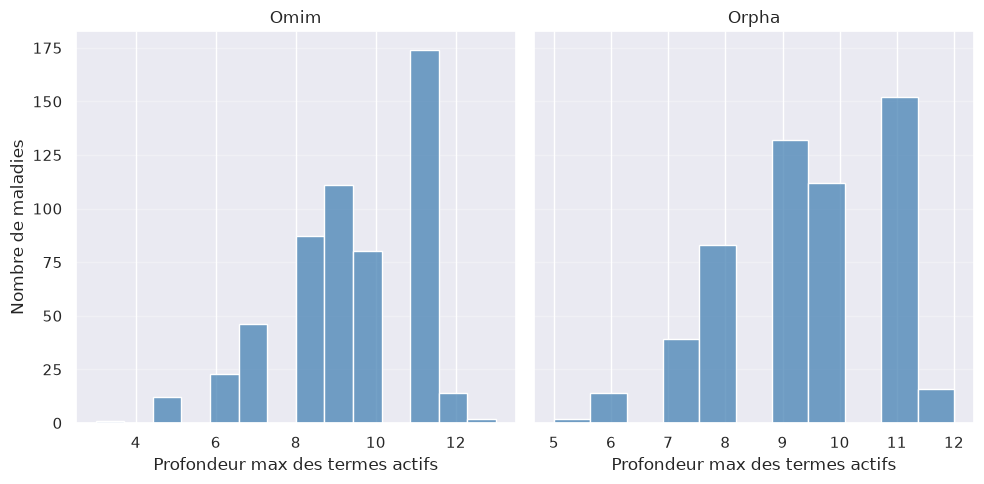

In [10]:
# Distribution de la profondeur maximale des termes pour les maladies
def depths_active_terms(df, depths):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)
    M = np.zeros((n, p), dtype=np.float32)
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            M[i, term_to_idx[t]] = depths[t]
    return M

depths_omim = depths_active_terms(df_omim, depths)
depths_orpha = depths_active_terms(df_orpha, depths)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
sns.set_theme()
ax = axes[0]
sns.histplot(np.array([np.max(row[row != 0]) for row in depths_omim]), ax=ax, color='steelblue')

ax.set_xlabel("Profondeur max des termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(np.array([np.max(row[row != 0]) for row in depths_orpha]), ax=ax, color='steelblue')

ax.set_xlabel("Profondeur max des termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

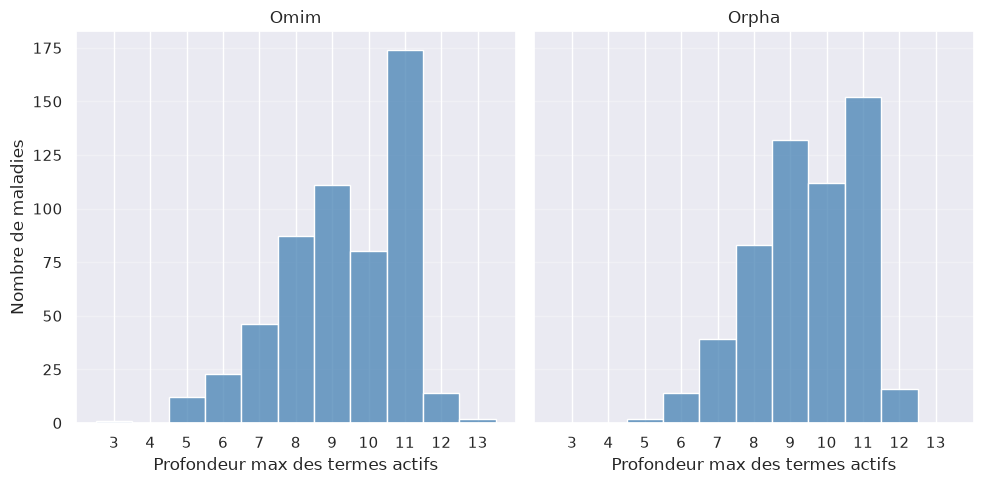

In [13]:
data_omim = np.array([np.max(row[row != 0]) for row in depths_omim])
data_orpha = np.array([np.max(row[row != 0]) for row in depths_orpha])

vmin = min(data_omim.min(), data_orpha.min())
vmax = max(data_omim.max(), data_orpha.max())

# bins centrés sur les entiers
bin_edges = np.arange(vmin, vmax + 2) - 0.5
bin_centers = np.arange(vmin, vmax + 1)  # = centres des bins = valeurs entières

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
sns.set_theme()

for ax, data, title in zip(axes, [data_omim, data_orpha], ["Omim", "Orpha"]):
    sns.histplot(data, ax=ax, color='steelblue', bins=bin_edges)
    ax.set_xlabel("Profondeur max des termes actifs")
    ax.set_ylabel("Nombre de maladies")
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(bin_centers)  # <-- force une graduation par bin/valeur entière

plt.tight_layout()
plt.show()

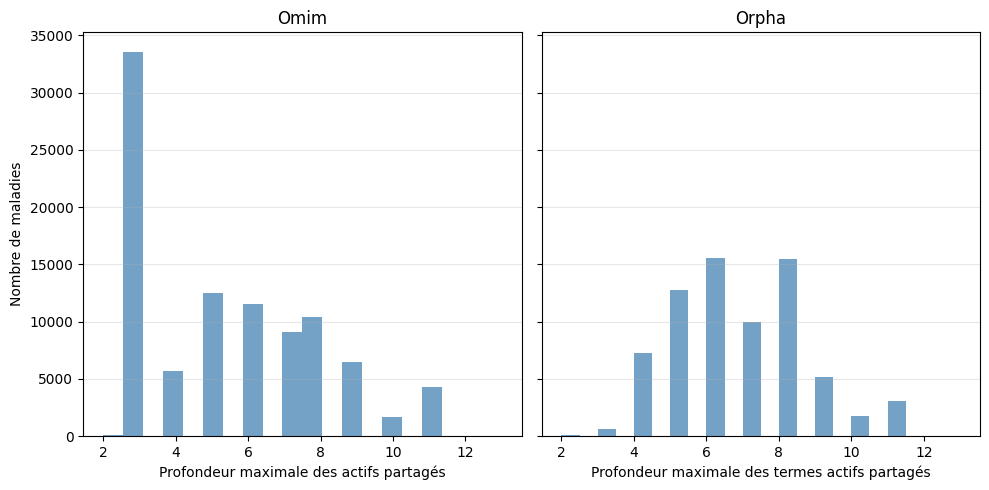

In [6]:
def max_depth_shared_terms(df, depths):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(depths.keys())
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)
    
    # Matrice binaire (n x p)
    M = np.zeros((n, p), dtype=np.float32)
    D = np.zeros(p, dtype=np.float32)  # vecteur des profondeurs
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            if t in term_to_idx:
                M[i, term_to_idx[t]] = 1.0
                D[term_to_idx[t]] = depths[t]
    rows, cols = np.tril_indices(n, k=-1)
    max_depths = np.array([
        np.max(D * M[rows[k]] * M[cols[k]]) if np.any(M[rows[k]] * M[cols[k]]) else 0.0
        for k in range(len(rows))
    ])
    return max_depths

max_shared_depths_omim = max_depth_shared_terms(df_omim, depths)
max_shared_depths_orpha = max_depth_shared_terms(df_orpha, depths)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(max_shared_depths_omim[max_shared_depths_omim!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur maximale des actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(max_shared_depths_orpha[max_shared_depths_orpha!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur maximale des termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("Profils OMIM")
print(f"Paires partageant des termes de profondeur au moins 4 : {np.round(len(max_shared_depths_omim[max_shared_depths_omim>3])/len(max_shared_depths_omim)*100, 2)}%")
print("Profils ORPHA")
print(f"Paires partageant des termes de profondeur au moins 4 : {np.round(len(max_shared_depths_orpha[max_shared_depths_orpha>3])/len(max_shared_depths_orpha)*100, 2)}%")

Profils OMIM
Paires partageant des termes de profondeur au moins 4 : 40.92%
Profils ORPHA
Paires partageant des termes de profondeur au moins 4 : 47.13%


In [7]:
def shared_active_terms_inter(df_omim, df_orpha):
    def get_active_matrix(df, all_terms):
        df_reset = df.reset_index(drop=True)
        n = df_reset.shape[0]
    
        #all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
        term_to_idx = {t: i for i, t in enumerate(all_terms)}
        p = len(all_terms)

        M = np.zeros((n, p), dtype=np.float32)
        for i, row in df_reset.iterrows():
            for t in row['list active terms']:
                M[i, term_to_idx[t]] = 1.0
        return M, term_to_idx
    all_terms = sorted(set(
        t for df in [df_omim.reset_index(drop=True), df_orpha.reset_index(drop=True)] 
        for terms in df['list active terms'] for t in terms))
    M0, t2id = get_active_matrix(df_omim, all_terms)
    M1, _ = get_active_matrix(df_orpha, all_terms)
    print(M0.shape)
    print(M1.shape)
    
    shared = (M0 @ M1.T).astype(np.float32)
    return shared, t2id

shared_matrix_inter, t2id = shared_active_terms_inter(df_omim, df_orpha)

(550, 5291)
(550, 5291)


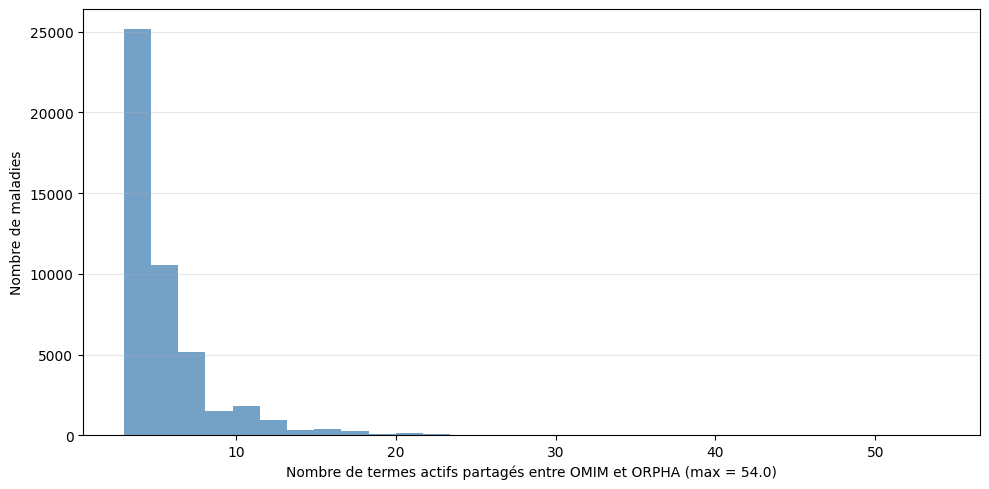

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax 
sns.histplot(shared_matrix_inter[shared_matrix_inter > 2].ravel(), bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes actifs partagés entre OMIM et ORPHA (max = {np.max(shared_matrix_inter)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(np.round(np.mean(shared_matrix_inter, axis=1), 2))
for i in range(shared_matrix_inter.shape[0]):
    print(f"Nombres de termes actifs partagés >3 : {shared_matrix_inter[shared_matrix_inter>3][i].sum()}/550")
# Ecart type pour chaque maladie OMIM (rapporté à la moyenne)
print(np.std(shared_matrix_inter, axis=1)/np.mean(shared_matrix_inter, axis=1))

Text(0, 0.5, 'Nb de maladies avec au moins k termes en commun')

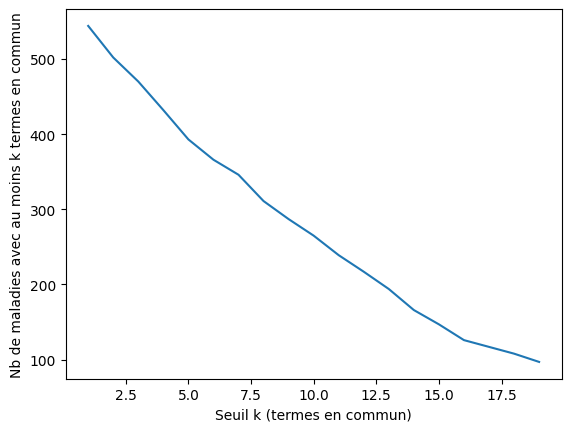

In [9]:
thresholds = range(1, 20)
results = []

for k in thresholds:
    adjacency = shared_matrix_inter >= k
    n = (adjacency.sum(axis=1) > 0).sum()
    results.append(n)

plt.plot(thresholds, results)
plt.xlabel("Seuil k (termes en commun)")
plt.ylabel("Nb de maladies avec au moins k termes en commun")

Nb de composantes : 151
Taille max : 385
Entrées isolées : 137


<Axes: >

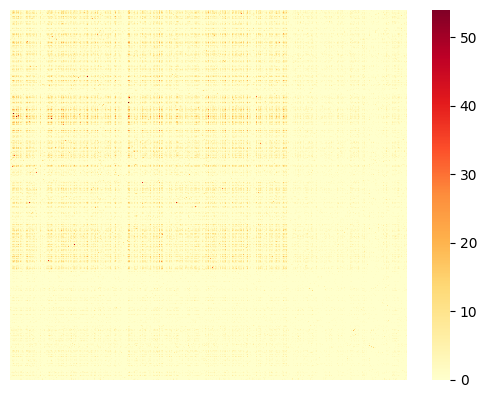

In [19]:
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

k = 10
adjacency = (shared_matrix_inter >= k).astype(np.float32)

n_components, labels = connected_components(csr_matrix(adjacency), directed=False)
sizes = np.bincount(labels)

print(f"Nb de composantes : {n_components}")
print(f"Taille max : {sizes.max()}")
print(f"Entrées isolées : {(sizes == 1).sum()}")

order = np.argsort(labels)
sorted_matrix = shared_matrix_inter[np.ix_(order, order)]
sns.heatmap(sorted_matrix, cmap="YlOrRd", xticklabels=False, yticklabels=False)